# Exploring Universes with Same Model, Different Evaluation, Different Fairness

This notebook lets you explore multiverse universes where:

- The **model design decisions** are the same (so the underlying model is fixed).
- The **evaluation decisions** differ (fairness grouping / subgroup exclusion / evaluation subset).
- The resulting **fairness metric** changes across those evaluation choices.

We work entirely in Python on top of the prepared aggregate data in `paper/data/df_agg_prepared.csv.gz`.

In [25]:
# 1. Set Up the Environment

import os
from pathlib import Path

# Set working directory to project root (adjust if needed)
PROJECT_ROOT = Path.cwd()
os.chdir(PROJECT_ROOT)

print("Project root:", PROJECT_ROOT)

Project root: /home/alberto/Documents/Uni/Courses/ExAndRel/Rel/Projects/fairml-multiverse


In [26]:
# 2. Import Required Libraries and Load Aggregated Universes

import pandas as pd
import numpy as np

agg_path = PROJECT_ROOT / "paper" / "data" / "df_agg_prepared.csv.gz"
print("Loading (tab-separated):", agg_path)

# The prepared file is tab-separated; parse it accordingly
df = pd.read_csv(agg_path, sep="\t", engine="python")
print(df.shape)

print("Columns:")
print(list(df.columns))

df.head()

Loading (tab-separated): /home/alberto/Documents/Uni/Courses/ExAndRel/Rel/Projects/fairml-multiverse/paper/data/df_agg_prepared.csv.gz
(1720320, 25)
Columns:
['sett_cutoff', 'sett_encode_categorical', 'sett_eval_exclude_subgroups', 'sett_eval_fairness_grouping', 'sett_eval_on_subset', 'sett_exclude_features', 'sett_exclude_subgroups', 'sett_model', 'sett_preprocess_age', 'sett_preprocess_income', 'sett_scale', 'sett_stratify_split', 'universe_id', 'fair_main_equalized_odds_difference', 'fair_main_equalized_odds_ratio', 'fair_main_demographic_parity_difference', 'fair_main_demographic_parity_ratio', 'perf_ovrl_accuracy', 'perf_ovrl_balanced accuracy', 'perf_ovrl_f1', 'perf_ovrl_precision', 'perf_ovrl_false positive rate', 'perf_ovrl_false negative rate', 'perf_ovrl_selection rate', 'perf_ovrl_count']
(1720320, 25)
Columns:
['sett_cutoff', 'sett_encode_categorical', 'sett_eval_exclude_subgroups', 'sett_eval_fairness_grouping', 'sett_eval_on_subset', 'sett_exclude_features', 'sett_exclude

,sett_cutoff,sett_encode_categorical,sett_eval_exclude_subgroups,sett_eval_fairness_grouping,sett_eval_on_subset,sett_exclude_features,sett_exclude_subgroups,sett_model,sett_preprocess_age,sett_preprocess_income,...,fair_main_demographic_parity_difference,fair_main_demographic_parity_ratio,perf_ovrl_accuracy,perf_ovrl_balanced accuracy,perf_ovrl_f1,perf_ovrl_precision,perf_ovrl_false positive rate,perf_ovrl_false negative rate,perf_ovrl_selection rate,perf_ovrl_count
0,raw_0.5,ordinal,exclude-in-eval,majority-minority,full,none,drop-smallest_race_2,rf,quantiles_3,quantiles_4,...,0.041969,0.863192,0.704044,0.657919,0.545788,0.628568,0.166437,0.517726,0.282885,27619
1,raw_0.5,ordinal,exclude-in-eval,majority-minority,locality-largest-only,none,drop-smallest_race_2,rf,quantiles_3,quantiles_4,...,0.092270,0.673209,0.708738,0.649653,0.516129,0.680851,0.116279,0.584416,0.228155,206
2,raw_0.5,ordinal,exclude-in-eval,majority-minority,locality-whitest-only,none,drop-smallest_race_2,rf,quantiles_3,quantiles_4,...,0.046875,0.812500,0.794118,0.700000,0.562500,0.642857,0.100000,0.500000,0.205882,68
3,raw_0.5,ordinal,exclude-in-eval,majority-minority,locality-city-la,none,drop-smallest_race_2,rf,quantiles_3,quantiles_4,...,0.064027,0.795022,0.681094,0.636499,0.517708,0.610140,0.176599,0.550403,0.280530,8156
4,raw_0.5,ordinal,exclude-in-eval,majority-minority,locality-city-sf,none,drop-smallest_race_2,rf,quantiles_3,quantiles_4,...,0.040227,0.885954,0.739857,0.712317,0.632997,0.661972,0.181818,0.393548,0.338902,419


In [27]:
# 3. Identify Design vs Evaluation Decisions

# All decision columns
sett_cols = [c for c in df.columns if c.startswith("sett_")]

# From the data preview, evaluation-related decisions live in these columns
# (these match the columns you just saw in the screenshot)
eval_decisions = [
    "sett_eval_exclude_subgroups",
    "sett_eval_fairness_grouping",
    "sett_eval_on_subset",
]

# Design decisions = everything else in sett_*, i.e., same model
design_decisions = [c for c in sett_cols if c not in eval_decisions]

metric_col = "fair_main_equalized_odds_difference"

len(sett_cols), len(design_decisions), len(eval_decisions)

(12, 9, 3)

In [28]:
# 4. Filter Universes: Same Model, Different Eval, Different Fairness

# Group by design decisions (same model), then check fairness spread over eval settings
groups = df.groupby(design_decisions, dropna=False)

rows = []
for keys, grp in groups:
    # If any of the eval_decisions are missing in this group, skip safely
    missing = [c for c in eval_decisions if c not in grp.columns]
    if missing:
        continue

    # Require more than one evaluation setting
    if grp[eval_decisions].drop_duplicates().shape[0] <= 1:
        continue
    # Require fairness to actually change across these eval settings
    if grp[metric_col].nunique() <= 1:
        continue
    rows.append(grp)

if rows:
    df_same_model = pd.concat(rows, ignore_index=True)
else:
    df_same_model = df.iloc[0:0].copy()

print("Rows with same model but differing eval + fairness:", len(df_same_model))

df_same_model.head()

Rows with same model but differing eval + fairness: 1716988


,sett_cutoff,sett_encode_categorical,sett_eval_exclude_subgroups,sett_eval_fairness_grouping,sett_eval_on_subset,sett_exclude_features,sett_exclude_subgroups,sett_model,sett_preprocess_age,sett_preprocess_income,...,fair_main_demographic_parity_difference,fair_main_demographic_parity_ratio,perf_ovrl_accuracy,perf_ovrl_balanced accuracy,perf_ovrl_f1,perf_ovrl_precision,perf_ovrl_false positive rate,perf_ovrl_false negative rate,perf_ovrl_selection rate,perf_ovrl_count
0,quantile_0.1,one-hot,exclude-in-eval,majority-minority,full,none,drop-name_race_Some Other Race alone,elasticnet,bins_10,bins_10000,...,0.006524,0.992768,0.434427,0.552729,0.550222,0.384385,0.862281,0.032262,0.899979,23325
1,quantile_0.1,one-hot,exclude-in-eval,majority-minority,locality-largest-only,none,drop-name_race_Some Other Race alone,elasticnet,bins_10,bins_10000,...,0.009917,0.988991,0.414773,0.540627,0.529680,0.367089,0.869565,0.049180,0.897727,176
2,quantile_0.1,one-hot,exclude-in-eval,majority-minority,locality-whitest-only,none,drop-name_race_Some Other Race alone,elasticnet,bins_10,bins_10000,...,0.406250,0.551724,0.363636,0.571429,0.447368,0.288136,0.857143,0.000000,0.893939,66
3,quantile_0.1,one-hot,exclude-in-eval,majority-minority,locality-city-la,none,drop-name_race_Some Other Race alone,elasticnet,bins_10,bins_10000,...,0.010903,0.987937,0.435441,0.548011,0.553213,0.388402,0.864965,0.039012,0.899890,6343
4,quantile_0.1,one-hot,exclude-in-eval,majority-minority,locality-city-sf,none,drop-name_race_Some Other Race alone,elasticnet,bins_10,bins_10000,...,0.038793,0.957547,0.433511,0.554921,0.547771,0.381657,0.860082,0.030075,0.898936,376


In [29]:
# 4b. Inspect all possible values per design decision

design_value_summary = {col: sorted(df[col].dropna().unique().tolist()) for col in design_decisions}



for col, vals in design_value_summary.items():

    print(f"{col}:")

    print("  ", vals)

    print()

sett_cutoff:
   ['quantile_0.1', 'quantile_0.25', 'raw_0.5']

sett_encode_categorical:
   ['one-hot', 'ordinal']

sett_exclude_features:
   ['none', 'race', 'race-sex', 'sex']

sett_exclude_subgroups:
   ['drop-name_race_Some Other Race alone', 'drop-smallest_race_1', 'drop-smallest_race_2', 'keep-all', 'keep-largest_race_2']

sett_model:
   ['elasticnet', 'gbm', 'logreg', 'rf']

sett_preprocess_age:
   ['bins_10', 'none', 'quantiles_3', 'quantiles_4']

sett_preprocess_income:
   ['bins_10000', 'none', 'quantiles_3', 'quantiles_4']

sett_scale:
   ['do-not-scale', 'scale']

sett_stratify_split:
   ['both', 'none', 'protected-attribute', 'target']



In [30]:
# 4c. Inspect all possible values per evaluation decision



eval_value_summary = {

    col: sorted(df[col].dropna().unique().tolist())

    for col in eval_decisions

}



for col, vals in eval_value_summary.items():

    print(f"{col}:")

    print("  ", vals)

    print()

sett_eval_exclude_subgroups:
   ['exclude-in-eval', 'keep-in-eval']

sett_eval_fairness_grouping:
   ['majority-minority', 'race-all']

sett_eval_on_subset:
   ['exclude-military', 'exclude-non-citizens', 'full', 'locality-city-la', 'locality-city-sf', 'locality-largest-only', 'locality-whitest-only']



In [31]:
# 5. Explore One Model Design Interactively (with performance + design + eval filters)

# Choose performance metric and threshold to filter candidate designs
perf_metric = "perf_ovrl_accuracy"  # e.g. 'perf_ovrl_accuracy', 'perf_ovrl_f1', 'perf_ovrl_weighted_acc'
perf_threshold = 0.6                # keep only designs with mean perf_metric above this

# Optional: specify desired design choices; leave value as None to not filter on that column
design_filters = {
    # "sett_model": "rf",
    # "sett_scale": "quantiles_4",
    # "sett_stratify_split": "both",
    "sett_exclude_subgroups": "keep-all",
}

# Optional: specify desired evaluation choices (applied later as a mask on df_one_model)
eval_filters = {
    # "sett_eval_fairness_grouping": "majority-minority",
    # "sett_eval_exclude_subgroups": "keep-in-eval",
    # "sett_eval_on_subset": "full",
}

# Start from all designs that have varying fairness across eval
design_perf = (
    df_same_model
    .groupby(design_decisions)[perf_metric]
    .mean()
    .reset_index()
    .rename(columns={perf_metric: f"mean_{perf_metric}"})
)

perf_col = f"mean_{perf_metric}"
design_perf_filtered = design_perf[design_perf[perf_col] >= perf_threshold]

# Apply design choice filters
for col, val in design_filters.items():
    if val is None:
        continue
    if col not in design_decisions:
        print(f"Warning: {col} not in design_decisions; skipping filter")
        continue
    design_perf_filtered = design_perf_filtered[design_perf_filtered[col] == val]

design_perf_filtered = design_perf_filtered.reset_index(drop=True)

print(f"Designs with {perf_metric} >= {perf_threshold} after design filters:", len(design_perf_filtered))

if len(design_perf_filtered) == 0:
    display("No designs found meeting the performance threshold and design filters.")
else:
    # Choose one model design (by index) among the filtered ones
    model_idx = 0  # change this to explore other high-performing designs

    # Get the selected design row (only design_decisions columns)
    design_row = design_perf_filtered.iloc[model_idx][design_decisions]
    display("Selected design (high performance):")
    display(design_row.to_frame().T)

    # Show mean performance for this design
    selected_perf = design_perf_filtered.iloc[model_idx][perf_col]
    print(f"Mean {perf_metric} for selected design: {selected_perf:.3f}")

    # Subset df_same_model to this design
    mask_design = (df_same_model[design_decisions] == design_row).all(axis=1)
    df_one_model = df_same_model.loc[mask_design].copy()

    # Apply eval filters as an additional mask (if any specified)
    if eval_filters:
        mask_eval = pd.Series(True, index=df_one_model.index)
        for col, val in eval_filters.items():
            if val is None:
                continue
            if col not in df_one_model.columns:
                print(f"Warning: {col} not in df_one_model; skipping eval filter")
                continue
            mask_eval &= (df_one_model[col] == val)
        df_one_model = df_one_model.loc[mask_eval].copy()

    # Show eval choices and fairness outcomes (design is fixed, so we only show eval + metric)
    cols_show = eval_decisions + [metric_col]
    if not df_one_model.empty:
        display(df_one_model[cols_show].sort_values(metric_col))
    else:
        display("No rows left after applying eval_filters for this design.")

Designs with perf_ovrl_accuracy >= 0.6 after design filters: 4080


'Selected design (high performance):'

,sett_cutoff,sett_encode_categorical,sett_exclude_features,sett_exclude_subgroups,sett_model,sett_preprocess_age,sett_preprocess_income,sett_scale,sett_stratify_split
0,raw_0.5,one-hot,none,keep-all,elasticnet,bins_10,bins_10000,do-not-scale,both


Mean perf_ovrl_accuracy for selected design: 0.721


,sett_eval_exclude_subgroups,sett_eval_fairness_grouping,sett_eval_on_subset,fair_main_equalized_odds_difference
1189748,exclude-in-eval,majority-minority,full,0.030537
1189762,keep-in-eval,majority-minority,full,0.030537
1189767,keep-in-eval,majority-minority,exclude-military,0.032418
1189753,exclude-in-eval,majority-minority,exclude-military,0.032418
1189765,keep-in-eval,majority-minority,locality-city-la,0.037127
1189751,exclude-in-eval,majority-minority,locality-city-la,0.037127
1189754,exclude-in-eval,majority-minority,exclude-non-citizens,0.037837
1189768,keep-in-eval,majority-minority,exclude-non-citizens,0.037837
1189749,exclude-in-eval,majority-minority,locality-largest-only,0.057504
1189763,keep-in-eval,majority-minority,locality-largest-only,0.057504


/tmp/ipykernel_79267/2058631469.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(df_plot["eval_strategy"], rotation=90, ha="right")
/tmp/ipykernel_79267/2058631469.py:26: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


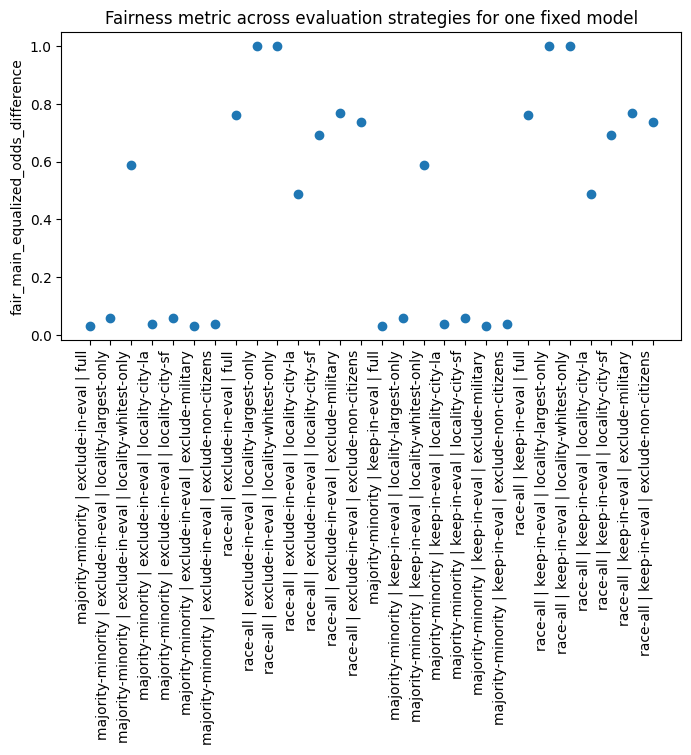

In [32]:
# 6. Simple Plot: Fairness vs Evaluation Choice for the Selected Model

import matplotlib.pyplot as plt

# Only plot if we actually have a selected model's rows
if "df_one_model" in globals() and not df_one_model.empty:
    fig, ax = plt.subplots(figsize=(8, 4))

    # Encode eval strategy as a string key
    df_plot = df_one_model.copy()
    df_plot["eval_strategy"] = (
        df_plot["sett_eval_fairness_grouping"].astype(str)
        + " | "
        + df_plot["sett_eval_exclude_subgroups"].astype(str)
        + " | "
        + df_plot["sett_eval_on_subset"].astype(str)
    )

    ax.scatter(
        df_plot["eval_strategy"],
        df_plot[metric_col],
    )
    ax.set_xticklabels(df_plot["eval_strategy"], rotation=90, ha="right")
    ax.set_ylabel(metric_col)
    ax.set_title("Fairness metric across evaluation strategies for one fixed model")
    plt.tight_layout()
    plt.show()
else:
    print("df_one_model is empty or not defined; run the previous cell first and ensure it finds a design.")